x 前5行:
 [[-0.16500505]
 [-0.13671324]
 [ 0.55260815]
 [-1.08854953]
 [-1.53282145]]
y 前5行:
 [ -4.06131068  -9.7011621   15.79313204 -41.34783754 -59.36190427]
真实权重coef: 39.80551570183919
真实bias: 1.5


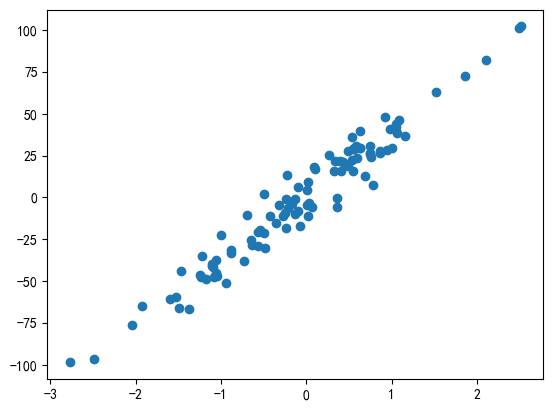

初始模型 weight: [[0.5597588]]
初始模型 bias: [-0.5563755]
epoch 1/100, 平均损失: 103.0140
epoch 5/100, 平均损失: 17.9670
epoch 10/100, 平均损失: 7.1026
epoch 15/100, 平均损失: 10.5574
epoch 20/100, 平均损失: 14.3631
epoch 25/100, 平均损失: 7.0324
epoch 30/100, 平均损失: 5.6753
epoch 35/100, 平均损失: 7.8301
epoch 40/100, 平均损失: 8.3684
epoch 45/100, 平均损失: 10.9132
epoch 50/100, 平均损失: 5.3378
epoch 55/100, 平均损失: 6.5808
epoch 60/100, 平均损失: 3.8388
epoch 65/100, 平均损失: 2.1864
epoch 70/100, 平均损失: 5.7028
epoch 75/100, 平均损失: 10.3662
epoch 80/100, 平均损失: 10.0052
epoch 85/100, 平均损失: 15.5902
epoch 90/100, 平均损失: 5.4047
epoch 95/100, 平均损失: 4.6876
epoch 100/100, 平均损失: 7.4175
训练后模型 weight: [[38.380398]]
训练后模型 bias: [1.0071957]


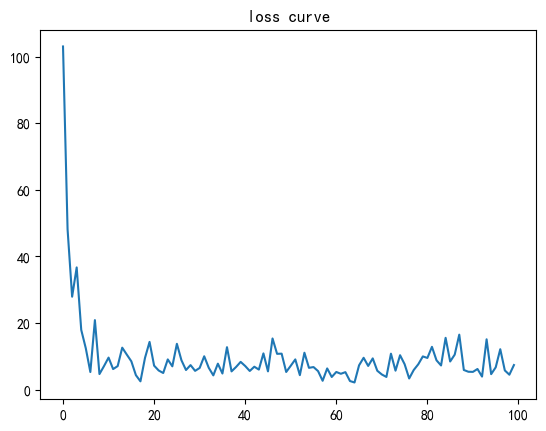

x 测试点前5个: [-2.769533  -2.7161415 -2.66275   -2.6093585 -2.555967 ]
模型预测 y_train 前5个: [-105.28858  -103.239395 -101.19021   -99.14102   -97.09184 ]
真实 y_true 前5个: [-108.74268609 -106.61741163 -104.49213716 -102.3668627  -100.24158823]


C:\Users\lenovo\AppData\Local\Temp\ipykernel_37784\3061952968.py:115: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_true = torch.tensor([v*coef + 1.5 for v in x])                        # 使用真实的权重和偏置


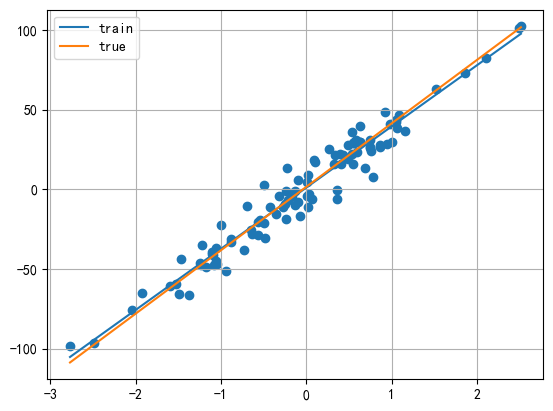

In [13]:
# 线性回归案例

import torch  # 导入pytorch主包
import torch.nn as nn  # 导入用于神经网络搭建的子模块
import torch.optim as optim  # 导入优化器模块
from  torch.utils.data import TensorDataset  # 导入张量数据集封装工具
from  torch.utils.data import DataLoader     # 导入数据加载器工具
import matplotlib.pyplot as plt  # 导入绘图工具
from sklearn.datasets import make_regression  # 导入sklearn用于生成回归数据的函数

# 1. 生成数据
# 生成一个线性回归测试数据集
# n_samples=100：生成100个样本（数据点）
# n_features=1：每个样本只有一个特征
# noise=10：为数据增加标准差为10的高斯噪声
# bias=1.5：真实模型的截距设置为1.5
# coef=True：返回真实的特征权重系数
# random_state=22：随机种子
x,y,coef = make_regression(n_samples=100, n_features=1, noise=10, bias=1.5, coef=True, random_state=22)

# 输出部分生成数据的前几个样本和真实权重
print("x 前5行:\n", x[:5])
print("y 前5行:\n", y[:5])
print("真实权重coef:", coef)
print("真实bias: 1.5")

# 2. 数据可视化
# 为了负号正常显示，设置matplotlib字体及负号支持
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用于正常显示负号

# 可选：绘制散点图观察数据的分布
plt.scatter(x, y)
plt.show()


# 3. 使用Pytorch模拟线性回归
# 3.1 构造数据集对象 Dataset
# TensorDataset将输入特征x和目标y转换为tensor，并封装为可迭代数据集形式
dataset = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))

# 3.2 创建数据加载器 DataLoader
# DataLoader用于每次按batch采样数据，shuffle=True表示每个epoch打乱数据顺序
# batch_size=10：每批次10个样本
dataLoader = DataLoader(dataset, batch_size=10, shuffle=True)

# 3.3 构造模型
# 构建一个输入特征为1，输出为1的线性回归模型
model = nn.Linear(in_features=1, out_features=1)

# 输出初始模型参数
print("初始模型 weight:", model.weight.data.numpy())
print("初始模型 bias:", model.bias.data.numpy())

# 3.4 构造损失函数, 优化函数
# 损失函数采用均方误差（MSELoss），优化方法为随机梯度下降（SGD），学习率0.01
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 3.5 训练模型
epochs = 100        # 训练轮数（epoch）
losses = []         # 用于记录每一轮的平均损失
total_loss = 0.     # 存放损失的累计和，用于计算平均损失
train_sample = 0.   # 记录已训练的样本数量

for epoch in range(epochs):  # 遍历每一个epoch
    for train_x, train_y in dataLoader:  # 遍历DataLoader中每个batch的数据
        
        total_loss = 0.     # 存放损失的累计和，用于计算平均损失
        train_sample = 0.   # 记录已训练的样本数量

        # 训练模型，预测结果（注意类型转换）
        # 将train_x转为float32类型并通过模型，获得预测值y_pred
        y_pred = model(train_x.type(torch.float32))

        # 计算损失（注意类型转换）
        # 损失函数输入的大小和类型需与模型一致
        loss = loss_fn(y_pred, train_y.reshape(-1,1).type(torch.float32))

        # 反向传播，更新参数
        optimizer.zero_grad()       # 梯度清零
        loss.backward()             # 反向传播计算梯度
        optimizer.step()            # 优化器更新参数

        # print("epoch:{}, loss:{}".format(epoch, loss.item()))
        total_loss += loss.item()        # 累加损失
        train_sample += len(train_y)     # 累加训练过的样本数

    # 单个epoch的平均训练损失
    # 记录平均损失值用于后续可视化
    losses.append(total_loss / train_sample)
    # 每10个epoch输出一次平均损失
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"epoch {epoch+1}/{epochs}, 平均损失: {losses[-1]:.4f}")

# 输出最终模型参数
print("训练后模型 weight:", model.weight.data.numpy())
print("训练后模型 bias:", model.bias.data.numpy())

# 4. 绘制损失变化曲线
# 绘制每个epoch损失下降的趋势
plt.plot(range(epochs), losses)
plt.title("loss curve")  # 设置标题
plt.show()  # 显示图像

# 5. 绘制拟合曲线
# 绘制原始数据的散点图
plt.scatter(x,y)            # 数据散点图

# 使用torch.linspace生成从x的最小值到最大值的100个点，作为拟合曲线的横坐标
x = torch.linspace(x.min(), x.max(), 100)
# 使用model训练得到的权重和偏置计算模型预测的y值（注意为线性关系y=wx+b）
y_train = torch.tensor([v*model.weight + model.bias for v in x])        # 使用训练的权重和偏置
# 使用make_regression返回的真实系数与既定偏置计算真实的y值
y_true = torch.tensor([v*coef + 1.5 for v in x])                        # 使用真实的权重和偏置

# 输出部分预测结果和真实结果对比
print("x 测试点前5个:", x[:5].numpy())
print("模型预测 y_train 前5个:", y_train[:5].numpy().flatten())
print("真实 y_true 前5个:", y_true[:5].numpy().flatten())

# 绘制曲线
plt.plot(x, y_train, label = 'train')   # 画出通过模型参数得到的拟合曲线
plt.plot(x, y_true, label = 'true')     # 画出真实的线性回归曲线
plt.grid()                              # 显示网格线
plt.legend()                            # 显示图例
plt.show()                              # 展示图像

## ========== PyTorch线性回归案例：函数方法详解 ==========

### 📚 本案例使用的所有重要函数方法汇总：

| 函数/方法 | 功能 | 语法示例 | 返回值类型 | 详细说明 |
|---------|------|---------|-----------|------|
| **`make_regression()`** | 生成回归数据 | `make_regression(n_samples=100, n_features=1, noise=10)` | `(X, y, coef)` | sklearn生成线性回归模拟数据 |
| **`torch.from_numpy()`** | numpy转张量 | `torch.from_numpy(array)` | `torch.Tensor` | 将numpy数组转换为PyTorch张量 |
| **`TensorDataset()`** | 创建数据集 | `TensorDataset(X_tensor, y_tensor)` | `Dataset对象` | 将特征和标签打包成数据集 |
| **`DataLoader()`** | 创建数据加载器 | `DataLoader(dataset, batch_size=10, shuffle=True)` | `DataLoader对象` | 批量加载数据，支持shuffle |
| **`nn.Linear()`** | 线性层 | `nn.Linear(in_features=1, out_features=1)` | `Linear对象` | 创建线性回归模型 y=wx+b |
| **`nn.MSELoss()`** | 均方误差损失 | `nn.MSELoss()` | `MSELoss对象` | 计算MSE损失：(1/n)Σ(y_pred-y_true)² |
| **`optim.SGD()`** | 随机梯度下降 | `optim.SGD(model.parameters(), lr=0.01)` | `SGD对象` | 优化器，lr是学习率 |
| **`.parameters()`** | 获取模型参数 | `model.parameters()` | `参数生成器` | 返回模型所有可训练参数 |
| **`model.forward()`** | 前向传播 | `model(x)` | `torch.Tensor` | 模型预测：y_pred = x @ w + b |
| **`.zero_grad()`** | 梯度清零 | `optimizer.zero_grad()` | `None` | 清空上一步的梯度，避免累积 |
| **`.backward()`** | 反向传播 | `loss.backward()` | `None` | 计算所有参数的梯度 |
| **`.step()`** | 参数更新 | `optimizer.step()` | `None` | 根据梯度更新模型参数 |
| **`.item()`** | 张量转数值 | `loss.item()` | `float` | 将标量张量转换为Python数值 |
| **`torch.linspace()`** | 等差数列 | `torch.linspace(start, end, steps)` | `torch.Tensor` | 创建等间距的数值序列 |
| **`.detach()`** | 分离计算图 | `tensor.detach()` | `torch.Tensor` | 从计算图中分离，避免梯度追踪 |
| **`.numpy()`** | 张量转numpy | `tensor.numpy()` | `numpy.ndarray` | 将PyTorch张量转换为numpy数组 |
| **`plt.scatter()`** | 散点图 | `plt.scatter(x, y)` | `None` | 绘制散点图 |
| **`plt.plot()`** | 线条图 | `plt.plot(x, y, label='name')` | `None` | 绘制线条图 |
| **`plt.show()`** | 显示图像 | `plt.show()` | `None` | 显示matplotlib图像 |

### 🔧 核心函数详细用法说明：

#### 1. **`make_regression()` - 数据生成**
```python
x, y, coef = make_regression(
    n_samples=100,      # 生成100个样本
    n_features=1,       # 每个样本1个特征
    noise=10,           # 添加标准差为10的噪声
    bias=1.5,           # 截距为1.5
    coef=True,          # 返回真实系数
    random_state=22     # 随机种子
)
# 返回值：
# x: 特征矩阵, shape (100, 1)
# y: 目标向量, shape (100,)
# coef: 真实权重系数, shape (1,)
```

#### 2. **`TensorDataset()` - 数据集封装**
```python
dataset = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))
# 功能：将特征和标签张量打包成数据集对象
# 返回值：Dataset对象，支持len()和索引访问
# 用法：dataset[i] 返回第i个样本的 (x[i], y[i])
```

#### 3. **`DataLoader()` - 数据加载器**
```python
dataLoader = DataLoader(dataset, batch_size=10, shuffle=True)
# 参数：
#   dataset: 数据集对象
#   batch_size: 每批样本数量
#   shuffle: 是否打乱数据顺序
# 返回值：DataLoader对象，支持迭代
# 用法：for batch_x, batch_y in dataLoader: ...
```

#### 4. **`nn.Linear()` - 线性层**
```python
model = nn.Linear(in_features=1, out_features=1)
# 参数：
#   in_features: 输入特征维度
#   out_features: 输出特征维度
# 返回值：Linear对象，自动创建weight和bias参数
# 数学公式：y = x @ weight + bias
# 访问参数：model.weight, model.bias
```

#### 5. **`nn.MSELoss()` - 均方误差损失**
```python
loss_fn = nn.MSELoss()
# 功能：计算均方误差
# 公式：MSE = (1/n) * Σ(y_pred - y_true)²
# 参数：reduction='mean' (默认)
# 返回值：MSELoss对象
# 用法：loss = loss_fn(y_pred, y_true)
```

#### 6. **`optim.SGD()` - 随机梯度下降优化器**
```python
optimizer = optim.SGD(model.parameters(), lr=0.01)
# 参数：
#   model.parameters(): 模型参数
#   lr: 学习率 (learning rate)
# 返回值：SGD对象
# 工作原理：w = w - lr * ∂Loss/∂w
```

#### 7. **训练三部曲**
```python
# 1. 梯度清零
optimizer.zero_grad()  # 防止梯度累积

# 2. 反向传播
loss.backward()  # 计算所有参数的梯度

# 3. 参数更新
optimizer.step()  # 使用梯度更新参数
```

#### 8. **`torch.linspace()` - 等差数列生成**
```python
x_plot = torch.linspace(x.min(), x.max(), 100)
# 参数：
#   start: 起始值
#   end: 结束值
#   steps: 生成点数
# 返回值：torch.Tensor，包含steps个等间距点
```

#### 9. **`.detach()` - 分离计算图**
```python
tensor.detach()  # 分离计算图，避免梯度追踪
# 用法：在绘图时使用，避免梯度累积
# 返回值：与原张量相同但不参与梯度计算的新张量
```

### 🎯 关键概念解释：

#### **自动求导（Autograd）**
- PyTorch的核心特性，自动计算梯度
- 通过`.backward()`触发反向传播
- 构建计算图，记录张量运算关系

#### **计算图（Computational Graph）**
- 张量运算的图形化表示
- 前向传播：从输入到输出
- 反向传播：从输出到输入计算梯度

#### **批处理（Batch Processing）**
- 一次性处理多个样本
- 提高计算效率，利用并行计算
- batch_size影响训练稳定性和速度

#### **epoch vs batch**
- **epoch**: 对整个数据集的一次完整训练
- **batch**: 一个epoch中的一次参数更新
- **iteration**: 一个batch的处理次数

### 📊 代码执行流程：

1. **数据生成** → `make_regression()`
2. **数据封装** → `TensorDataset()`
3. **数据加载** → `DataLoader()`
4. **模型创建** → `nn.Linear()`
5. **损失函数** → `nn.MSELoss()`
6. **优化器** → `optim.SGD()`
7. **训练循环** → 遍历epochs和batches
8. **结果可视化** → 损失曲线和拟合曲线

### 💡 学习建议：

1. **理解张量操作**：PyTorch的核心是张量操作
2. **掌握梯度下降**：优化算法的核心原理
3. **学会调试**：观察loss曲线判断训练状态
4. **调参技巧**：学习率、batch_size等参数的影响
5. **扩展应用**：从线性回归到复杂神经网络

这个案例展示了PyTorch深度学习框架的基础用法，是理解神经网络训练流程的关键。

epoch 05, mse=0.076785
epoch 10, mse=0.069960
epoch 15, mse=0.059056
epoch 20, mse=0.042502
epoch 25, mse=0.037052
epoch 30, mse=0.033684


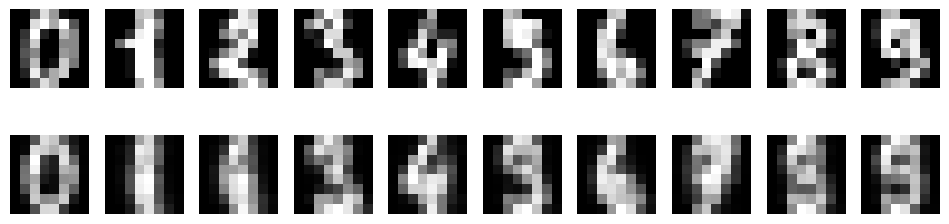

z (features) shape: torch.Size([10, 16])
first sample z: tensor([ 0.6663, -0.5475, -1.3685, -6.7388, -1.6000,  2.9791, -0.3774, -0.4058,
         0.0997,  0.6563, -2.2458, -5.0038, -3.2514, -0.2092, -0.1899,  0.5490])


(tensor([[8.1593e-04, 1.6930e-02, 3.2855e-01, 8.3317e-01, 7.4695e-01, 3.6895e-01,
          8.5040e-02, 6.8899e-03, 1.5242e-03, 2.9434e-02, 8.3899e-01, 7.6777e-01,
          6.5745e-01, 7.9185e-01, 1.4823e-01, 5.7914e-03, 1.5287e-03, 3.1294e-01,
          9.6082e-01, 2.3399e-01, 1.1578e-01, 8.4240e-01, 3.9628e-01, 3.6927e-03,
          3.0875e-03, 4.3108e-01, 9.0466e-01, 1.8733e-01, 1.0959e-01, 6.7510e-01,
          6.1877e-01, 5.3971e-03, 7.7911e-04, 4.4229e-01, 6.3221e-01, 1.0118e-01,
          4.7590e-02, 5.3450e-01, 5.5877e-01, 5.4120e-04, 5.2607e-04, 2.9294e-01,
          7.2382e-01, 1.7998e-02, 4.3908e-02, 6.4907e-01, 3.5872e-01, 1.7279e-03,
          2.4014e-03, 7.2316e-02, 7.5987e-01, 5.1758e-01, 5.3382e-01, 7.6927e-01,
          9.8873e-02, 2.1891e-03, 7.5617e-04, 4.4275e-03, 3.0423e-01, 8.1451e-01,
          8.1711e-01, 2.1835e-01, 1.1198e-02, 2.4884e-03],
         [3.5066e-04, 1.6099e-03, 8.1835e-02, 6.2554e-01, 8.2450e-01, 2.9081e-01,
          1.8256e-02, 3.5370e-04, 3.538

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from torch.utils.data import DataLoader, TensorDataset

# 1) 加载数据：8x8 手写数字图片，每个像素值范围为0~16
digits = load_digits()  # 加载手写数字数据集
X = digits.data.astype(np.float32) / 16.0   # 将原始像素归一化到 0~1
X_tensor = torch.from_numpy(X)               # 转换为PyTorch张量

# 利用TensorDataset和DataLoader包装数据，方便批量训练
loader = DataLoader(TensorDataset(X_tensor), batch_size=128, shuffle=True)

# 2) 定义自编码器模型（AutoEncoder），包括编码器和解码器
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # 编码器部分：64维输入 -> 32维隐藏层 -> 16维“特征向量z”
        self.encoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),           # 激活函数ReLU
            nn.Linear(32, 16)    # 输出为16维表示z
        )
        # 解码器部分：16维z还原回64维原始像素
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),           # 激活函数ReLU
            nn.Linear(32, 64),
            nn.Sigmoid()         # 输出限制在0~1之间，匹配像素归一化
        )

    def forward(self, x):
        """
        前向传播函数
        参数:
            x: 输入数据，shape=[batch_size, 64]
        返回:
            x_hat: 重建后的输出，shape=[batch_size, 64]
            z:     编码得到的中间特征，shape=[batch_size, 16]
        """
        z = self.encoder(x)         # 编码获得特征z
        x_hat = self.decoder(z)     # 解码重建输入
        return x_hat, z             # 返回输出和特征

# 实例化模型、损失函数和优化器
model = AutoEncoder()                  # 自编码器模型
loss_fn = nn.MSELoss()                 # 均方误差损失
opt = optim.Adam(model.parameters(), lr=1e-3)  # Adam优化器

# 3) 训练模型：目标是让输出x_hat尽量接近输入x
epochs = 30  # 训练轮数
for ep in range(epochs):
    total = 0.0  # 累加总损失
    n = 0        # 样本数
    for (x_batch,) in loader:
        x_hat, z = model(x_batch)        # 前向传播，获得重建和特征
        loss = loss_fn(x_hat, x_batch)   # 计算重建损失

        opt.zero_grad()    # 梯度清零
        loss.backward()    # 反向传播
        opt.step()         # 参数更新

        total += loss.item() * x_batch.size(0)  # 累加当前batch损失
        n += x_batch.size(0)                    # 累加batch样本数

    # 每5个epoch输出一次当前训练集的平均MSE
    if (ep + 1) % 5 == 0:
        print(f"epoch {ep+1:02d}, mse={total/n:.6f}")

# 4) 可视化对比：展示前10张原图和重建图，观察重建效果
with torch.no_grad():   # 在评估或可视化时不计算梯度
    x0 = X_tensor[:10]              # 取前10个样本
    x_hat0, z0 = model(x0)          # 获得其重建结果和特征表示

# 创建2行10列的子图：第一行为输入原图，第二行为自编码器重建的图
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].imshow(x0[i].reshape(8,8), cmap="gray")      # 原图
    axes[0, i].axis("off")
    axes[1, i].imshow(x_hat0[i].reshape(8,8), cmap="gray")  # 重建图
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Input", rotation=0, labelpad=20)
axes[1, 0].set_ylabel("Recon", rotation=0, labelpad=20)
plt.show()

# 5) 输出自编码器“特征z”的形状和首个样本的z向量
print("z (features) shape:", z0.shape)  # (10, 16)
print("first sample z:", z0[0])

# 返回重建图片和特征z，便于后续分析或测试
# x_hat0: [10, 64] 重建图片
# z0:     [10, 16] 特征向量
(x_hat0, z0)
